# Compare a DAG with the true DAG

Causal discovery methods will provide a list of discovered edges between factors. It can be useful to plot this discovered DAG in the same format as the true DAG so that missing or extra edges are easier to pick out visually.

This notebook shows how to format the edges in a DAG to mark them as correct, incorrect, or missing.

## Code setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import os

# Add modules to path:
import sys
sys.path.append('../')  # path to dir containing modules
from modules.create_data import create_stroke_data
from modules.utils_dag import categorise_edges_vs_true, \
    make_legend_entry_for_line, make_formatting_for_edges

## Load in true DAG effects

The values are 0 where the row has no effect on the column and 1 where it does.

In [2]:
p = os.path.join('data', 'synthetic_links.csv')
df_effects = pd.read_csv(p, index_col=0)

In [3]:
df_effects

,afib,warfarin,nihss,thrombolysis,mortality_prob_no_treatment,mortality_probability
row_causes_column,,,,,,
year,0,0,0,0,1,0
age,1,0,1,0,1,0
ethnicity,0,0,0,0,1,1
male,0,0,0,0,1,0
afib,0,1,0,0,1,0
warfarin,0,0,0,1,0,0
shoe_size,0,0,0,0,0,0
nihss,0,0,0,1,1,0
thrombolysis_time,0,0,0,0,0,1


Fill in missing columns for nodes that have no parents. These nodes are currently in the index but not in the columns. Then make sure that the column features are in the same order as the index features.

In [4]:
parent_nodes = list(set(df_effects.index) - set(df_effects.columns))

df_effects_full = df_effects.copy()
df_effects_full[parent_nodes] = 0
df_effects_full = df_effects_full[df_effects_full.index]

In [5]:
df_effects_full

,year,age,ethnicity,male,afib,warfarin,shoe_size,nihss,thrombolysis_time,thrombolysis,mortality_prob_no_treatment,mortality_probability
row_causes_column,,,,,,,,,,,,
year,0,0,0,0,0,0,0,0,0,0,1,0
age,0,0,0,0,1,0,0,1,0,0,1,0
ethnicity,0,0,0,0,0,0,0,0,0,0,1,1
male,0,0,0,0,0,0,0,0,0,0,1,0
afib,0,0,0,0,0,1,0,0,0,0,1,0
warfarin,0,0,0,0,0,0,0,0,0,1,0,0
shoe_size,0,0,0,0,0,0,0,0,0,0,0,0
nihss,0,0,0,0,0,0,0,0,0,1,1,0
thrombolysis_time,0,0,0,0,0,0,0,0,0,0,0,1


## Make a "discovered" effects df

Invent an effects dataframe similar to the true one as though it is the result of a discovery algorithm. Start with all links the same and then deliberately change some values.

In [6]:
# Start with the real answer:
df_effects_disc = df_effects_full.copy()

# Modify some effects:
df_effects_disc.loc['shoe_size', 'thrombolysis_time'] = 1  # incorrect
df_effects_disc.loc['ethnicity', 'mortality_prob_no_treatment'] = 0  # missing
df_effects_disc.loc['afib', 'thrombolysis'] = 1  # incorrect
df_effects_disc.loc['warfarin', 'thrombolysis'] = 0  # missing

## Convert df to graphs

In [ ]:
G_true = nx.from_pandas_adjacency(df_effects_full, create_using=nx.DiGraph)
G_disc = nx.from_pandas_adjacency(df_effects_disc, create_using=nx.DiGraph)

edges_true = list(G_true.edges())
edges_disc = list(G_disc.edges())

Pick out which edges in the discovered DAG match the true DAG (correct), are not in the true DAG (incorrect), or were not found (missing).

Check the docstring for the function imported from the utils module:

In [9]:
print(categorise_edges_vs_true.__doc__)


Decide whether found edges are correct, incorrect, or missing.

Correct edges are in both lists. Incorrect edges are in only the
new list, and missing edges are in only the true list.
Each edge is a tuple (start, end) to show direction.

Inputs
------
edges_disc - list. Discovered edges.
edges_true - list. Expected edges.

Returns
-------
d - dict. Dictionary of correct, incorrect, and missing edges.
    Each entry is a list of tuples, one tuple per edge.



In [10]:
edges_dict = categorise_edges_vs_true(edges_disc, edges_true)

Check the contents of the dictionary we just made:

In [19]:
for edge_cat, edges in edges_dict.items():
    print(edge_cat, edges[:2])

correct [('afib', 'warfarin'), ('afib', 'mortality_prob_no_treatment')]
incorrect [('afib', 'thrombolysis'), ('shoe_size', 'thrombolysis_time')]
missing [('ethnicity', 'mortality_prob_no_treatment'), ('warfarin', 'thrombolysis')]


## Setup for plots

Place nodes at these positions:

In [12]:
# Node positions:
pos = {
    'year': (4, 0),
    'age': (3, 0),
    'ethnicity': (6, 0),
    'male': (5, 0),
    'afib': (1, -1),
    'warfarin': (1, -2),
    'shoe_size': (7, 0),
    'nihss': (3, -1),
    'thrombolysis_time': (7, -3),
    'thrombolysis': (2, -3),
    'mortality_prob_no_treatment': (4, -2),
    'mortality_probability': (6, -4),
}

# Pick out coordinates of most extreme nodes:
node_x_min = min([p[0] for p in pos.values()])
node_x_max = max([p[0] for p in pos.values()])
node_y_min = min([p[1] for p in pos.values()])
node_y_max = max([p[1] for p in pos.values()])

Set up appearance of effect arrows:

In [13]:
edge_kw = {
    'correct': dict(color='k', lw=1, label='Correct', linestyle=None),
    'incorrect': dict(color='red', lw=1, label='Incorrect', linestyle=None),
    'missing': dict(color='grey', lw=1, label='Missing', linestyle=':'),
}

Set up a legend for these arrows.

Check the docstring for the function imported from the utils module:

In [14]:
print(make_legend_entry_for_line.__doc__)


Make line from input format dictionary for a legend entry.

The format dictionary is passed to Line2D().
Example line format dictionary:
dict(color='k', lw=1, label='Correct', linestyle=None)

Make a legend of result using: ax.legend(handles=[legend_element])

Inputs
------
edge_format_dict - dict. Contains formatting for the line.

Returns
-------
legend_element - matplotlib artist. A Line2D instance to match the
                 input formatting.



In [15]:
# Set up contents for a legend for these lines:
legend_elements = [make_legend_entry_for_line(d) for d in edge_kw.values()]

For each edge in turn, set up the formatting. The networkx plotting function needs a list of edges, list of colours of the edges, and list of linestyles of the edges. For example, if there are 10 correct, 5 incorrect, and 2 missing lines, then each formatting list must be 17 items long.

Gather all edges and line formatting using the edge dict values and keys to make sure each list is gathered in the same order.

In [16]:
print(make_formatting_for_edges.__doc__)


Set up formatting for edges to be drawn on a DAG.

For each type of formatting, create a single list that combines all
edge categories. These lists can be used in a networkx plot.
Returns a dict of single lists. For example, if
there are 10 correct, 5 incorrect, and 2 missing lines, then each
formatting list in the dict must be 17 items long.

Expect edges_dict and edge_kw to have the same keys. If there are
entries in edges_dict that are missing in edge_kw, a warning is
raised.

Example inputs:
edges_dict = {'correct': [('a', 'b'), ('b', 'c')],
              'incorrect': [('a', 'd')]}
edge_kw = {'correct': dict(color='k'),
           'incorrect': dict(color='red')}

Inputs
------
edges_dict - dict. Edges by category. For example, keys could be
             'correct', 'incorrect', and 'missing'. Values are
             lists of tuples, one tuple per edge
             (start node, end node).
edge_kw    - dict. Formatting for each category of edges. Each
             value is a dict of 

In [17]:
edge_plot_dict = make_formatting_for_edges(edges_dict, edge_kw)

## Plot comparative DAG

This is mostly the same code as in the basic DAG demo. The additions are in the call to ax.legend() to explain the arrow formatting, and the keywords "edgelist", "edge_color" and "style" in draw_networkx(), which explicitly gives the edges to draw and the colour and linestyle formatting for each edge.

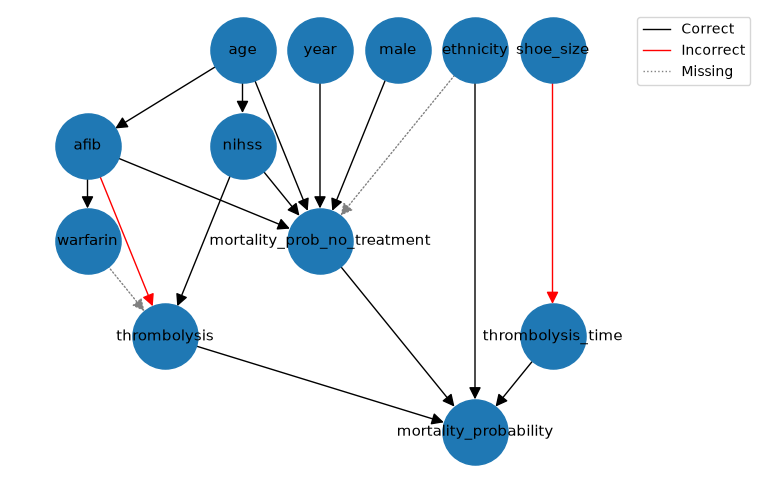

In [18]:
# Create graph:
fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx(
    G_disc,
    pos,
    ax=ax,
    with_labels=True,
    arrows=True,
    edgelist=edge_plot_dict['edges'],
    edge_color=edge_plot_dict['color'],
    style=edge_plot_dict['linestyle'],
    node_size=2200,
    font_size=11,
    arrowsize=18,
)

# Modify axis limits for breathing room around labels:
ax.set_xlim(node_x_min-1, node_x_max+1)
# ax.set_ylim(node_y_min-1, node_y_max+1)

# Remove border around ax:
for s in ['top', 'bottom', 'left', 'right']:
    ax.spines[s].set_visible(False)

# Legend for arrow formatting:
ax.legend(handles=legend_elements, bbox_to_anchor=(1, 1), loc='upper left')

plt.show()